# 14_hybrid_deeponet_cnn_train.ipynb

Гибридная модель **DeepONet + CNN refinement** для задачи `sensor -> speed map`.

## Идея
- **DeepONet block** строит устойчивую **coarse reconstruction**;
- **CNN refinement head** получает:
  - coarse map,
  - spatial feature map, декодированный из branch-encoder,
  - и предсказывает **residual correction**;
- итоговая карта:
  \[
  \hat c = c_{coarse} + \alpha \cdot c_{refine}
  \]
  где `alpha` — trainable scalar.

## Зачем
У обычного DeepONet получаются хорошие средние метрики, но более сглаженные картинки.
Гибридная схема должна сохранить устойчивость operator-подхода и добавить более локальную детализацию через CNN-head.

## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Сама гибридная модель обучается в **PyTorch** и использует GPU, если он доступен.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "hybrid_deeponet_cnn_v1",
    "batch_size": 8,
    "epochs": 220,
    "patience": 35,
    "lr": 1e-3,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,

    "branch_width": 192,
    "trunk_width": 192,
    "trunk_hidden": 256,
    "num_fourier_features": 24,
    "dropout": 0.0,

    "refine_channels": 32,
    "refine_loss_weight": 1.0,

    "scheduler_factor": 0.5,
    "scheduler_patience": 8,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'hybrid_deeponet_cnn_v1',
 'batch_size': 8,
 'epochs': 220,
 'patience': 35,
 'lr': 0.001,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'branch_width': 192,
 'trunk_width': 192,
 'trunk_hidden': 256,
 'num_fourier_features': 24,
 'dropout': 0.0,
 'refine_channels': 32,
 'refine_loss_weight': 1.0,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
assert len(train_files) > 0 and len(val_files) > 0 and len(test_files) > 0

train: 6200
val: 1000
test: 800


In [5]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` через j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=1000.0,
        pml_size=16,
    )
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_194683/2997561755.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom_complex: (16, 256) complex64
time: 7.231446027755737 sec


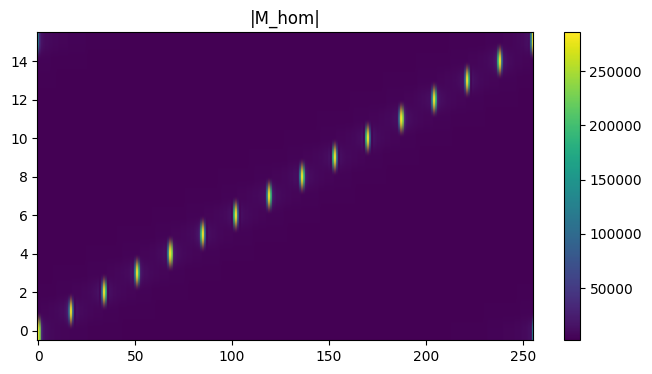

In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

plt.figure(figsize=(8, 4))
plt.imshow(np.abs(M_hom_complex), aspect="auto", origin="lower")
plt.title("|M_hom|")
plt.colorbar()
plt.show()

## 2. Dataset with target normalization to `[-1, 1]`

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTHybridDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {
                "path": str(self.paths[idx]),
                "x_scale": x_scale,
            },
        )

In [10]:
ds_train = USCTHybridDataset(
    train_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

ds_val = USCTHybridDataset(
    val_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

ds_test = USCTHybridDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, meta0 = ds_train[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7392016053199768 0.5010437965393066
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.529296875}


## 3. Trunk coordinate grid

In [11]:
yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords)

print("coords_t:", coords_t.shape)

coords_t: torch.Size([36864, 2])


## 4. Hybrid DeepONet + CNN model

In [12]:
class BranchEncoderHybrid(nn.Module):
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )

    def forward(self, x):
        h = self.conv1(x)
        h = self.conv2(h)
        h = self.conv3(h)
        feat = self.conv4(h)          # [B, 192, 2, 32]
        branch_vec = self.fc(feat)    # [B, out_dim]
        return branch_vec, feat

class TrunkNetHybrid(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]

        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [
            coords,
            torch.sin(y_proj),
            torch.cos(y_proj),
            torch.sin(x_proj),
            torch.cos(x_proj),
        ]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class CNNRefinementHead(nn.Module):
    def __init__(self, in_feat_ch=192, refine_ch=32):
        super().__init__()
        self.decode = nn.Sequential(
            nn.ConvTranspose2d(in_feat_ch, 128, kernel_size=4, stride=2, padding=1),  # 4x64
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),          # 8x128
            nn.GELU(),
            nn.ConvTranspose2d(64, refine_ch, kernel_size=4, stride=2, padding=1),    # 16x256
            nn.GELU(),
        )
        self.post = nn.Sequential(
            nn.Conv2d(refine_ch + 1, refine_ch, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refine_ch, refine_ch, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refine_ch, 1, kernel_size=3, padding=1),
        )

    def forward(self, coarse_map, feat_map):
        h = self.decode(feat_map)
        h = h[:, :, :H, :W]  # crop from 16x256 to 16x192? no, HxW = 480? wait output H,W from dataset
        if h.shape[-2:] != coarse_map.shape[-2:]:
            h = torch.nn.functional.interpolate(h, size=coarse_map.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([coarse_map, h], dim=1)
        return self.post(x)

class HybridDeepONetCNN(nn.Module):
    def __init__(self, branch_width=192, trunk_width=192, trunk_hidden=256, num_fourier_features=24, dropout=0.0, refine_channels=32):
        super().__init__()
        self.width = int(branch_width)
        self.branch = BranchEncoderHybrid(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetHybrid(
            width=trunk_width,
            hidden=trunk_hidden,
            num_fourier_features=num_fourier_features,
            dropout=dropout,
        )
        self.bias = nn.Parameter(torch.zeros(1))
        self.refine_head = CNNRefinementHead(in_feat_ch=192, refine_ch=refine_channels)
        self.refine_alpha = nn.Parameter(torch.tensor(0.1, dtype=torch.float32))

    def forward(self, x, coords, return_parts=False):
        branch_vec, feat_map = self.branch(x)
        trunk_vec = self.trunk(coords)

        coarse = torch.matmul(branch_vec, trunk_vec.t()) / math.sqrt(self.width) + self.bias
        coarse = coarse.view(x.shape[0], 1, H, W)

        refine = self.refine_head(coarse, feat_map)
        out = coarse + self.refine_alpha * refine

        if return_parts:
            return out, coarse, refine
        return out

## 5. Metrics and helpers

In [13]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def train_one_epoch(model, loader, optimizer, criterion, device, coords_device, scaler=None, refine_loss_weight=1.0):
    model.train()
    total_loss = 0.0
    total_main = 0.0
    total_coarse = 0.0

    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is None:
            pred, coarse, _ = model(x, coords_device, return_parts=True)
            loss_main = criterion(pred, c)
            loss_coarse = criterion(coarse, c)
            loss = loss_main + refine_loss_weight * 0.25 * loss_coarse
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred, coarse, _ = model(x, coords_device, return_parts=True)
                loss_main = criterion(pred, c)
                loss_coarse = criterion(coarse, c)
                loss = loss_main + refine_loss_weight * 0.25 * loss_coarse
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        bs = x.shape[0]
        total_loss += float(loss.item()) * bs
        total_main += float(loss_main.item()) * bs
        total_coarse += float(loss_coarse.item()) * bs

    n = len(loader.dataset)
    return {
        "total": total_loss / n,
        "main": total_main / n,
        "coarse": total_coarse / n,
    }

@torch.no_grad()
def eval_loss(model, loader, criterion, device, coords_device, refine_loss_weight=1.0):
    model.eval()
    total_loss = 0.0
    total_main = 0.0
    total_coarse = 0.0

    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)

        pred, coarse, _ = model(x, coords_device, return_parts=True)
        loss_main = criterion(pred, c)
        loss_coarse = criterion(coarse, c)
        loss = loss_main + refine_loss_weight * 0.25 * loss_coarse

        bs = x.shape[0]
        total_loss += float(loss.item()) * bs
        total_main += float(loss_main.item()) * bs
        total_coarse += float(loss_coarse.item()) * bs

    n = len(loader.dataset)
    return {
        "total": total_loss / n,
        "main": total_main / n,
        "coarse": total_coarse / n,
    }

@torch.no_grad()
def evaluate_dataset(model, dataset, device, coords_device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)

    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        pred, coarse, refine = model(x.unsqueeze(0).to(device), coords_device, return_parts=True)
        pred = pred[0, 0].cpu().numpy()
        coarse = coarse[0, 0].cpu().numpy()
        target = c[0].numpy()

        pred = np.clip(pred, -1.0, 1.0)
        coarse = np.clip(coarse, -1.0, 1.0)

        pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
        coarse_phys = denorm_c_from_minus1_1(coarse, c_min, c_max)
        target_phys = denorm_c_from_minus1_1(target, c_min, c_max)

        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["coarse_rmse"] = rmse(coarse_phys, target_phys)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)

    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 6. DataLoaders

In [14]:
train_loader = DataLoader(
    ds_train,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    ds_val,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

print("num train batches:", len(train_loader))
print("num val batches:", len(val_loader))

num train batches: 775
num val batches: 125


## 7. Training

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
coords_device = coords_t.to(device)

model = HybridDeepONetCNN(
    branch_width=CFG["branch_width"],
    trunk_width=CFG["trunk_width"],
    trunk_hidden=CFG["trunk_hidden"],
    num_fourier_features=CFG["num_fourier_features"],
    dropout=CFG["dropout"],
    refine_channels=CFG["refine_channels"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG["scheduler_factor"],
    patience=CFG["scheduler_patience"],
    min_lr=CFG["min_lr"],
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "hybrid_best.pt"

train_history = []
val_history = []
lr_history = []
epochs_no_improve = 0

t0 = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    train_stats = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        coords_device,
        scaler=scaler,
        refine_loss_weight=CFG["refine_loss_weight"],
    )
    val_stats = eval_loss(
        model,
        val_loader,
        criterion,
        device,
        coords_device,
        refine_loss_weight=CFG["refine_loss_weight"],
    )

    scheduler.step(val_stats["total"])

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_stats)
    val_history.append(val_stats)
    lr_history.append(current_lr)

    print(
        f"epoch {epoch:03d} | "
        f"train_total={train_stats['total']:.6f} | "
        f"val_total={val_stats['total']:.6f} | "
        f"train_main={train_stats['main']:.6f} | "
        f"val_main={val_stats['main']:.6f} | "
        f"train_coarse={train_stats['coarse']:.6f} | "
        f"val_coarse={val_stats['coarse']:.6f} | "
        f"alpha={float(model.refine_alpha.detach().cpu()):.4f} | "
        f"lr={current_lr:.6e}"
    )

    if val_stats["total"] < best_val:
        best_val = val_stats["total"]
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break

t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

epoch 001 | train_total=0.040278 | val_total=0.032095 | train_main=0.031435 | val_main=0.024474 | train_coarse=0.035370 | val_coarse=0.030484 | alpha=0.0992 | lr=1.000000e-03
epoch 002 | train_total=0.031213 | val_total=0.028265 | train_main=0.023434 | val_main=0.020863 | train_coarse=0.031116 | val_coarse=0.029608 | alpha=0.1093 | lr=1.000000e-03
epoch 003 | train_total=0.027874 | val_total=0.025922 | train_main=0.020408 | val_main=0.018878 | train_coarse=0.029864 | val_coarse=0.028175 | alpha=0.1154 | lr=1.000000e-03
epoch 004 | train_total=0.025790 | val_total=0.024150 | train_main=0.018665 | val_main=0.017292 | train_coarse=0.028502 | val_coarse=0.027435 | alpha=0.1196 | lr=1.000000e-03
epoch 005 | train_total=0.024336 | val_total=0.023078 | train_main=0.017431 | val_main=0.016464 | train_coarse=0.027617 | val_coarse=0.026453 | alpha=0.1194 | lr=1.000000e-03
epoch 006 | train_total=0.023152 | val_total=0.022042 | train_main=0.016432 | val_main=0.015606 | train_coarse=0.026880 | val

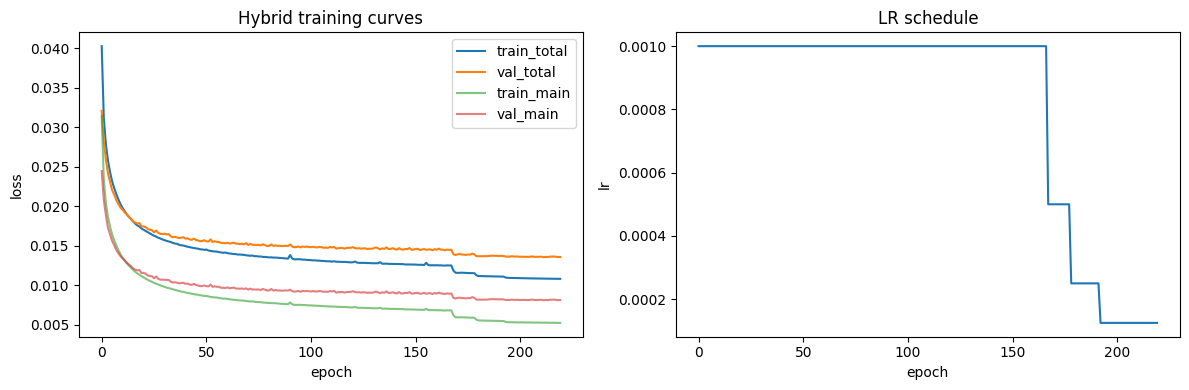

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot([x["total"] for x in train_history], label="train_total")
ax[0].plot([x["total"] for x in val_history], label="val_total")
ax[0].plot([x["main"] for x in train_history], label="train_main", alpha=0.6)
ax[0].plot([x["main"] for x in val_history], label="val_main", alpha=0.6)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Hybrid training curves")
ax[0].legend()

ax[1].plot(lr_history)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")

plt.tight_layout()
plt.show()

## 8. Best checkpoint evaluation

In [17]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, coords_device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, coords_device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, coords_device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))

print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))

print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 49.283332790559335,
  "mse_std": 17.326340488608604,
  "rmse_mean": 6.91249630589639,
  "rmse_std": 1.225041883029248,
  "relative_l2_mean": 0.00463290813844651,
  "relative_l2_std": 0.0008236425725371165,
  "psnr_mean": 29.109666502972903,
  "psnr_std": 1.5513278459553752,
  "coarse_rmse_mean": 14.02726171801167,
  "coarse_rmse_std": 3.656921667286387
}

VAL SUMMARY
{
  "mse_mean": 76.55312380599976,
  "mse_std": 68.67620237937575,
  "rmse_mean": 8.190106482505799,
  "rmse_std": 3.078194205981173,
  "relative_l2_mean": 0.005489564583171159,
  "relative_l2_std": 0.002063325632711526,
  "psnr_mean": 27.98061132598664,
  "psnr_std": 2.7449366907126267,
  "coarse_rmse_mean": 13.903643555641175,
  "coarse_rmse_std": 3.5171210144039478
}

TEST SUMMARY
{
  "mse_mean": 398.1901983547211,
  "mse_std": 206.7710285169566,
  "rmse_mean": 19.218925791978837,
  "rmse_std": 5.368714034840614,
  "relative_l2_mean": 0.012880032720859162,
  "relative_l2_std": 0.00359316827

## 9. Visualization

In [18]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device, coords_device, c_min, c_max):
    x, c, meta = dataset[idx]
    pred, coarse, refine = model(x.unsqueeze(0).to(device), coords_device, return_parts=True)

    pred = np.clip(pred[0, 0].cpu().numpy(), -1.0, 1.0)
    coarse = np.clip(coarse[0, 0].cpu().numpy(), -1.0, 1.0)
    refine = refine[0, 0].cpu().numpy()
    target = c[0].numpy()

    pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
    coarse_phys = denorm_c_from_minus1_1(coarse, c_min, c_max)
    target_phys = denorm_c_from_minus1_1(target, c_min, c_max)

    fig, ax = plt.subplots(1, 5, figsize=(25, 4))

    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(coarse_phys, origin="lower")
    ax[1].set_title("coarse DeepONet")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(refine, origin="lower")
    ax[2].set_title("CNN residual")
    plt.colorbar(im2, ax=ax[2])

    im3 = ax[3].imshow(pred_phys, origin="lower")
    ax[3].set_title("hybrid prediction")
    plt.colorbar(im3, ax=ax[3])

    im4 = ax[4].imshow(np.abs(pred_phys - target_phys), origin="lower")
    ax[4].set_title("|pred-target|")
    plt.colorbar(im4, ax=ax[4])

    plt.tight_layout()
    plt.show()
    print(meta["path"])

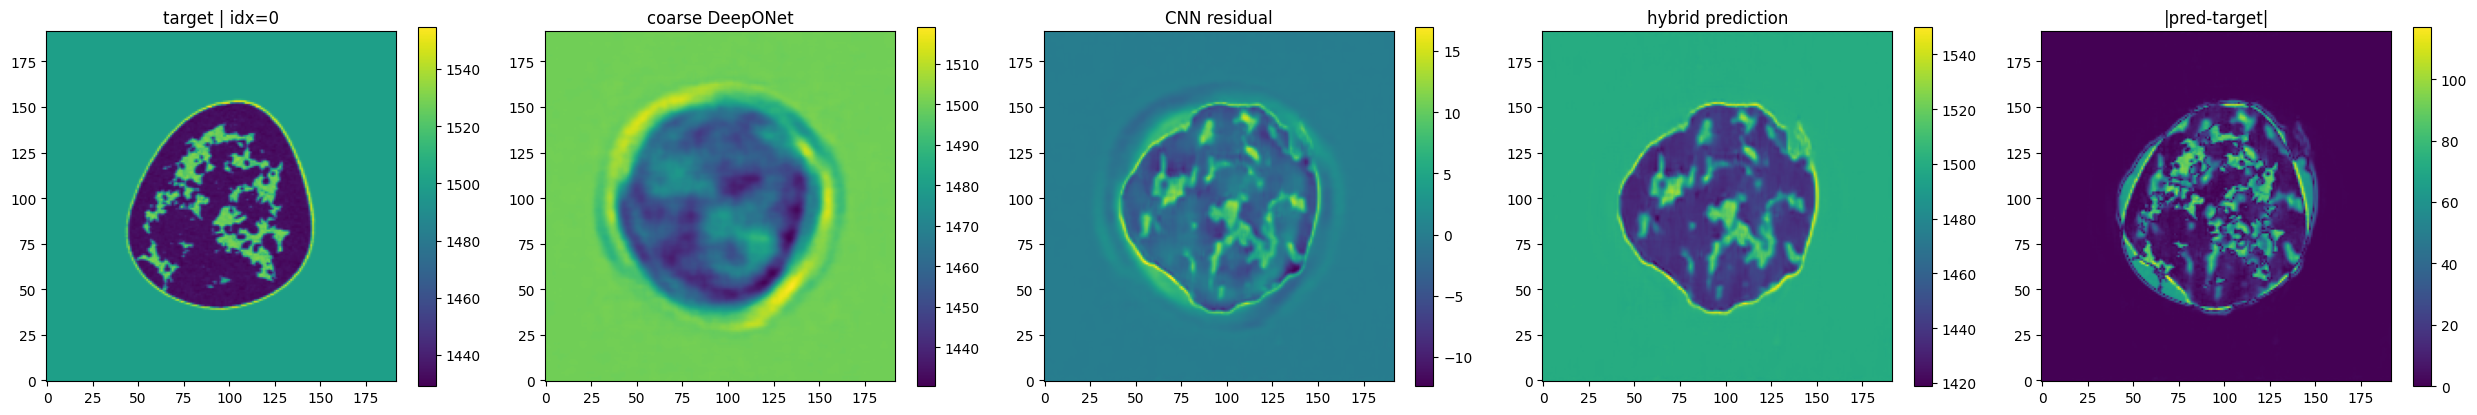

/workspace/usct_dataset_v2/test/sample_00000.npz


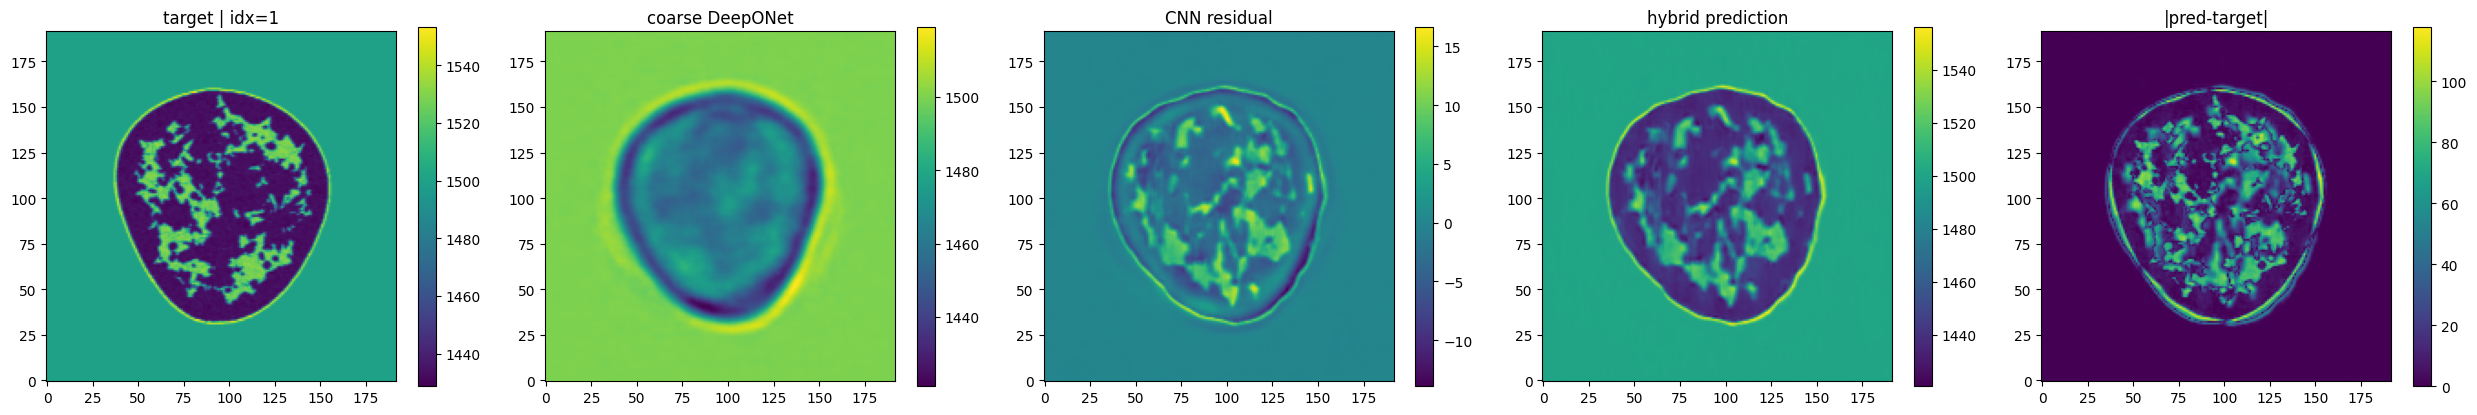

/workspace/usct_dataset_v2/test/sample_00001.npz


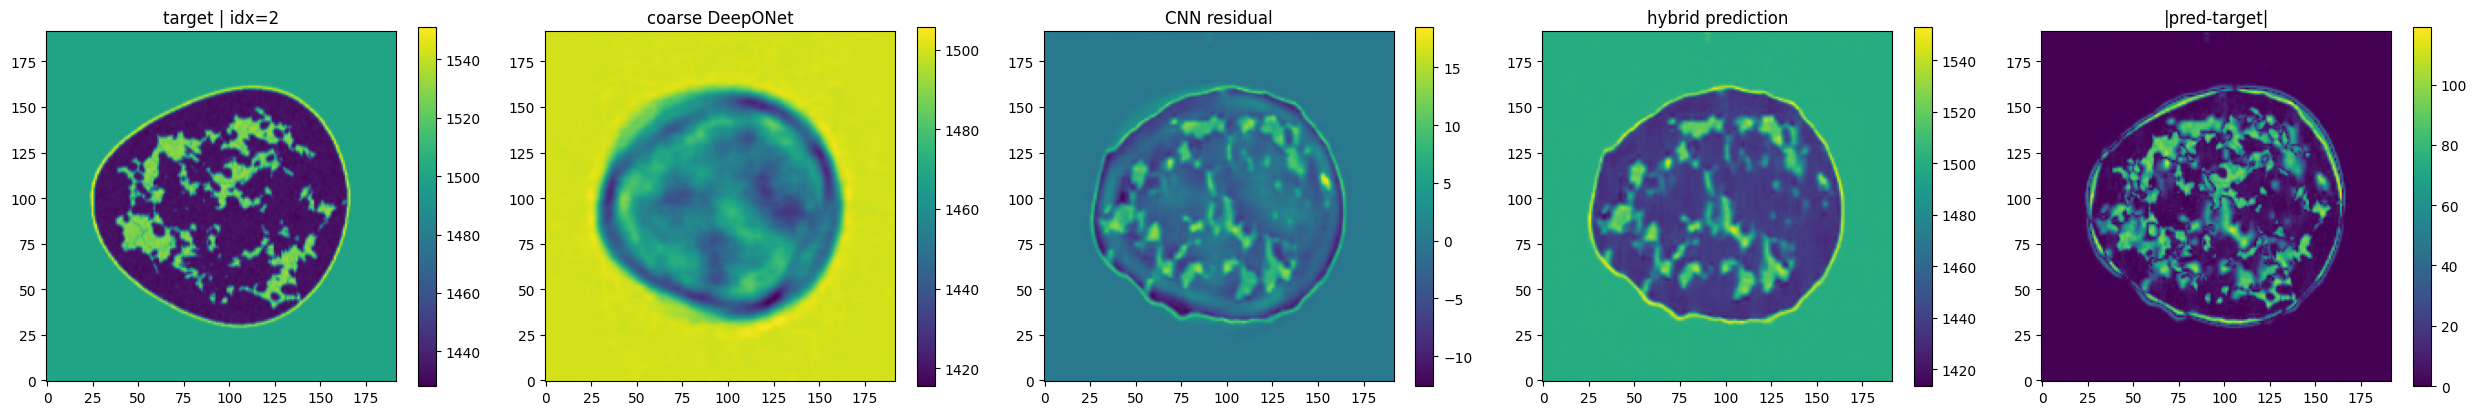

/workspace/usct_dataset_v2/test/sample_00002.npz


In [19]:
for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device, coords_device, stats["c_min"], stats["c_max"])

## 10. Save artifacts

In [20]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(RUN_DIR / "train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_total=np.array([x["total"] for x in train_history], dtype=np.float32),
    val_total=np.array([x["total"] for x in val_history], dtype=np.float32),
    train_main=np.array([x["main"] for x in train_history], dtype=np.float32),
    val_main=np.array([x["main"] for x in val_history], dtype=np.float32),
    train_coarse=np.array([x["coarse"] for x in train_history], dtype=np.float32),
    val_coarse=np.array([x["coarse"] for x in val_history], dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/hybrid_deeponet_cnn_v1
